In [ ]:
# atomstring = '''
# Fe -0.64147387529051 0.51990405379180 0.11450483185168
# O 0.33915564253394 2.18819453520299 -0.84159903476570
# H 0.65823736209818 2.99799985286513 -0.40575899522591
# O -1.29914529040912 -0.20924466129350 -1.80322550106302
# H -2.11419692217693 0.03267722517314 -2.27701147100162
# O 0.01237770373627 1.24396717111997 2.03533113813669
# H 0.83097217272839 1.00756306178418 2.50577204385612
# O -1.62284672685044 -1.15048542622041 1.07007991103536
# H -1.94592790838151 -1.95766677806096 0.63237073377438
# O -2.41866907277644 1.66373032346654 0.25658821238371
# H -2.55381601393967 2.56024091790599 -0.09930153080408
# O 1.13404022498401 -0.62623224778001 -0.02436092147139
# H 1.26370551457750 -1.52400168391753 0.33034524187694
# H -3.28110369794222 1.35873477131317 0.59094893393907
# H -0.81032015579443 -0.82248643308581 -2.37966496653734
# H 1.99795010138314 -0.32692539271158 -0.36001715946551
# H 0.57998322602479 2.26642229799559 -1.78148703231078
# H -0.47668197075682 1.85673194452426 2.61208351578631
# H -1.85653031374812 -1.23356353207299 2.011352050005
# '''

In [3]:
import numpy as np
from pyscf import gto, scf, mp, cc, lib

# mol = gto.M(atom = atomstring,
#             basis = {
#                 'default': 'ccpvdz-dk',
#                 'Fe': 'ccpwcvtz-dk'
#                 },
#             verbose = 4,
#             unit = 'angstrom',
#             symmetry = 0,
#             charge = 2,
#             spin = 4,
#             max_memory = 20000,
#             )

path2chk = "./hs_tdz_mf.chk"
mol = lib.chkfile.load_mol(path2chk)

mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk(path2chk)
# mf.init_guess = 'chk'
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

# stable = False
# for i in range(10):
#     print(f'mf stability test {i+1}')
#     if not stable:
#         mo_i, _, stable,_ = mf.stability(return_status=True)
#         dm = mf.make_rdm1(mo_i,mf.mo_occ)
#         mf = mf.newton()
#         mf.kernel(dm0=dm)
#     elif stable:
#         print(f'mf energy: {mf.e_tot}, stability {stable}')
#         break





******** <class 'pyscf.soscf.newton_ah.SecondOrdersfX2C1eDFUHF'> ********
method = SecondOrdersfX2C1eDFUHF
initial guess = minao
damping factor = 0
level_shift factor = 0.5
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 100
direct_scf = False
chkfile to save SCF result = /tmp/tmp1m__5ki7
max_memory 20000 MB (current use 1792 MB)
number electrons alpha = 44  beta = 40


******** <class 'pyscf.x2c.sfx2c1e.SpinFreeX2CHelper'> ********
approx = 1e
xuncontract = 1
******** <class 'pyscf.x2c.sfx2c1e.sfX2C1eDFUHF'> Newton solver flags ********
SCF tol = 1e-09
conv_tol_grad = None
max. SCF cycles = 100
direct_scf = False
chkfile to save SCF result = /tmp/tmp1m__5ki7
max_cycle_inner = 12
max_stepsize = 0.05
ah_start_tol = 1e+09
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_start_cycle = 1
ah_max_cycle = 40
ah_grad_trust_region = 2.5
kf_interval = 4
kf_trust_region = 5
canoni

np.float64(-1727.5438115926079)

In [4]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (235, 235)
frozen orbitals 11
max_memory 20000 MB (current use 2180 MB)
E(DFUMP2) = -1729.38153669198  E_corr = -1.83772509936831
E(SCS-DFUMP2) = -1729.2986611043  E_corr = -1.75484951169576
E_corr(same-spin) = -0.519716085630242
E_corr(oppo-spin) = -1.31800901373806
-1.8377250993683052


In [5]:
from afqmc.lno_afqmc import lno_afqmc, tools
lo_coeff, frag_list, frag_name = tools.iao_fragment(mf, frag_type='h2heavy', more_loc='pm')

Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.006798560655  |g|= 0.0421664
macro= 1  f(x)= 55.011902632284  delta_f= 0.00510407  |g|= 0.0199265  5 KF 27 Hx
macro= 2  f(x)= 55.013323663683  delta_f= 0.00142103  |g|= 0.00511249  5 KF 30 Hx
macro= 3  f(x)= 55.013391340587  delta_f= 6.76769e-05  |g|= 0.00106101  2 KF 10 Hx
macro= 4  f(x)= 55.013399281354  delta_f= 7.94077e-06  |g|= 0.00210417  1 KF 4 Hx
macro= 5  

In [7]:

options = {
           'n_prop_steps': 50,
           'n_blocks': 600,
           'n_walkers': 300,
           'max_memory': 2000,
           'mix_precision': 'False',
           'n_batch': 1,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

threshs = [3e-5, 1e-5, 3e-6, 1e-6, 3e-7, 0.0]
size = np.zeros(len(threshs))
emp = np.zeros(len(threshs))
# ecc = np.zeros(len(threshs))
# emp = np.zeros(len(threshs))
# emp = np.zeros(len(threshs))

for i,lno_thresh in enumerate(threshs):
    emp[i], _, _, _, size[i] \
        = lno_afqmc.run_afqmc(
            mf,
            lo_coeff, 
            frag_list,
            frag_name,
            lno_thresh = lno_thresh,
            qmc_options = options, 
            chol_cut = 1e-5, 
            target_qmc_err = 1e-3, 
            run_frag = None, 
            nfrozen = None,
            run_mp = True,
            run_cc = False,
            run_qmc = False,
            plot_las = False,
            )


 ******* LNO-CALCULATION ******* 

LNO THRESHOLD = 3e-05
LNO freezes at least the chemcore orbitals for each element!
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.


========================== LNO-FRAGMENT [Fe0] 1/(7,7) ==========================
LNO THRESHOLD - [0.00030000000000000003, 3e-05]
PySCF NumPy Threads - 16
nfrozen occupied orbitals:  [29, 27]
nactive occupied orbitals:  [15, 13]
nactive virtual orbitals:   [87, 76]
nfrozen virtual orbitals:   [115, 130]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

LNO-MP2 Fragment Energy:  -0.55302898
LNO-CCSD Fragment Energy: 0.00000000
LNO-CCSD time (s):        2.33


======================== LNO-FRAGMENT [O1H2H16] 2/(7,7) ========================
LNO THRESHOLD - [0.00030000000000000003, 3e-05]
PySCF NumPy Threads - 16
nfrozen occupied orbitals:  [35, 33]
nacti

[102. 140. 165. 176. 212. 235.]
[-1.79960817 -1.82277248 -1.83236495 -1.83527083 -1.83682167 -1.8377251 ]
-1.83772509682127


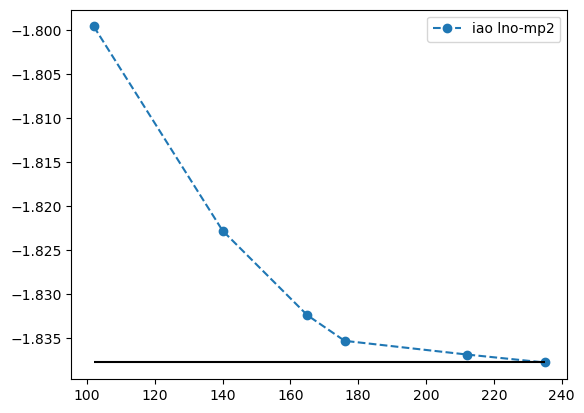

In [8]:
emp2_ref = -1.83772509682127
print(size)
print(emp)
print(emp2_ref)
from matplotlib import pyplot as plt
plt.plot(size, emp, "o--", color="C0", label="iao lno-mp2")
plt.hlines(emp2_ref, xmin=min(size), xmax=max(size), colors='k')
plt.legend()
plt.show()

[102. 140. 165. 176. 212.]
[-1.79960817 -1.82277248 -1.83236495 -1.83527083 -1.83682167]
-1.83772509682127


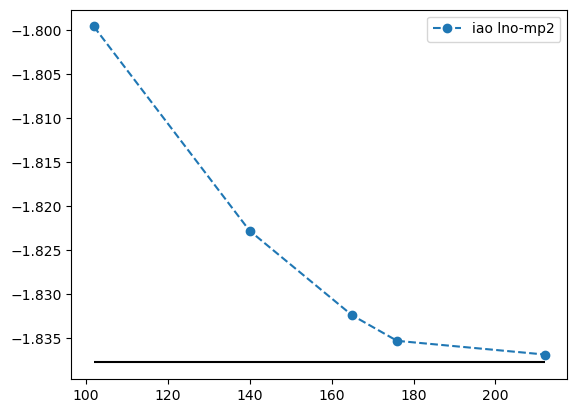

In [5]:
emp2_ref = -1.83772509682127
print(size)
print(emp)
print(emp2_ref)
from matplotlib import pyplot as plt
plt.plot(size, emp, "o--", color="C0", label="iao lno-mp2")
plt.hlines(emp2_ref, xmin=min(size), xmax=max(size), colors='k')
plt.legend()
plt.show()

In [6]:
lo_coeff, frag_list, frag_name = tools.iao_fragment(mf, frag_type='h2heavy', more_loc='pm', x2c=False)

size2 = np.zeros(len(threshs))
emp2 = np.zeros(len(threshs))

for i,lno_thresh in enumerate(threshs):
    emp2[i], _, _, _, size2[i] \
        = lno_afqmc.run_afqmc(
            mf,
            lo_coeff, 
            frag_list,
            frag_name,
            lno_thresh = lno_thresh,
            qmc_options = options, 
            chol_cut = 1e-5, 
            target_qmc_err = 1e-3, 
            run_frag = None, 
            nfrozen = None,
            run_mp = True,
            run_cc = False,
            run_qmc = False,
            plot_las = False,
            )

Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.007199067274  |g|= 0.0424834
macro= 1  f(x)= 55.01244205268  delta_f= 0.00524299  |g|= 0.0188388  5 KF 27 Hx
macro= 2  f(x)= 55.013660332377  delta_f= 0.00121828  |g|= 0.005654  5 KF 30 Hx
macro= 3  f(x)= 55.013795909653  delta_f= 0.000135577  |g|= 0.000664919  6 KF 34 Hx
macro= 4  f(x)= 55.013796278827  delta_f= 3.69175e-07  |g|= 0.000374968  5 KF 29 Hx
macro= 5  f(x)= 55.013796372551  delta_f= 9.37241e-08  |g|= 6.73321e-05  2 KF 7 Hx
macro X = 5  f(x)= 55.

[102. 140. 165. 176. 212.]
[-1.79960817 -1.82277248 -1.83236495 -1.83527083 -1.83682167]
[103. 141. 165. 176. 212.]
[-1.79980067 -1.82280286 -1.83236731 -1.83527129 -1.83682197]
-1.83772509682127


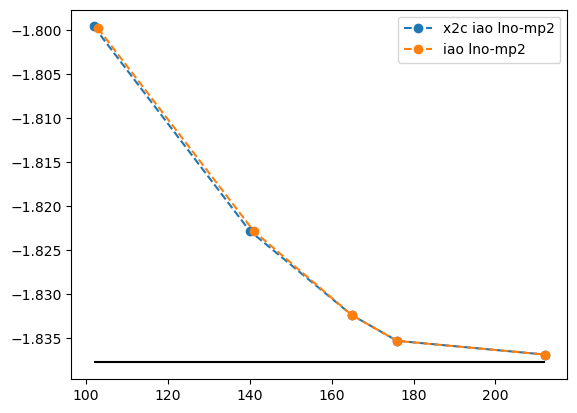

In [7]:
print(size)
print(emp)
print(size2)
print(emp2)
print(emp2_ref)
from matplotlib import pyplot as plt
plt.plot(size, emp, "o--", color="C0", label="x2c iao lno-mp2")
plt.plot(size2, emp2, "o--", color="C1", label="iao lno-mp2")
plt.hlines(emp2_ref, xmin=min(size), xmax=max(size), colors='k')
plt.legend()
plt.show()